In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
import numpy as np
import json
from scipy.stats import binom
from scipy.integrate import solve_ivp
import os
import sys
from matplotlib.colors import LinearSegmentedColormap, Normalize, LogNorm

sys.path.append(os.path.abspath("."))
save_dir = "Files"
os.makedirs(save_dir, exist_ok=True)

In [ ]:
# network functions
def load_group_statistics(network, path="Data/group_statistics.txt"):
    """
    Load group-size and membership statistics for a given network.

    The function reads a JSON file containing empirical group statistics and
    returns the corresponding membership distribution, group-size distribution,
    and structural metadata required by the wAMEs framework.

    Parameters
    ----------
    network : str
        Name of the network to load.
    path : str, optional
        Path to the JSON file containing the group statistics.

    Returns
    -------
    tuple
        ``(gm, pn, mmax, nmax, state_meta)``, where

        - ``gm`` is the membership distribution,
        - ``pn`` is the group-size distribution,
        - ``mmax`` is the maximum membership,
        - ``nmax`` is the maximum group size,
        - ``state_meta`` is the structural metadata returned by
          ``get_state_meta``.

    Raises
    ------
    FileNotFoundError
        If the statistics file does not exist.
    KeyError
        If the requested network is not found in the file.
    ValueError
        If the loaded distributions are empty or invalid.
    """
    with open(path, "r") as f:
        results = json.load(f)

    if network not in results:
        available = ", ".join(sorted(results.keys()))
        raise KeyError(
            f"Network '{network}' not found in '{path}'. "
            f"Available networks: {available}"
        )

    data = results[network]

    n_vals = data["group_size_n"]
    p_vals = data["group_size_p"]
    k_vals = data["membership_k"]
    g_vals = data["membership_g"]

    if len(n_vals) == 0 or len(k_vals) == 0:
        raise ValueError(f"Network '{network}' has empty group statistics.")

    nmax = int(max(n_vals))
    mmax = int(max(k_vals))

    pn = np.zeros(nmax + 1, dtype=float)
    gm = np.zeros(mmax + 1, dtype=float)

    for n, p in zip(n_vals, p_vals):
        pn[int(n)] = float(p)

    for k, g in zip(k_vals, g_vals):
        gm[int(k)] = float(g)
        
    pmax = float(np.max(pn[2:]))

    state_meta = get_state_meta(mmax, nmax, gm, pn)

    return gm, pn, mmax, nmax, pmax, state_meta

def get_state_meta(mmax, nmax, gm, pn):
    """
    From https://github.com/gstonge/gcm

    Return a tuple containing structural metadata for the system.

    Parameters
    ----------
    mmax : int
        Maximum membership.
    nmax : int
        Maximum group size, with nmax >= 2.
    gm : array_like
        Membership distribution of length mmax + 1.
    pn : array_like
        Group-size distribution of length nmax + 1.

    Returns
    -------
    tuple
        Tuple containing useful arrays that describe the structure.
    """
    m = np.arange(0, mmax + 1)
    imat = np.zeros((nmax + 1, nmax + 1))
    nmat = np.zeros((nmax + 1, nmax + 1))

    for n in range(2, nmax + 1):
        imat[n, 0:n + 1] = np.arange(n + 1)
        nmat[n, 0:n + 1] = np.ones(n + 1) * n

    pnmat = np.outer(pn, np.ones(nmax + 1))
    return (mmax, nmax, m, np.array(gm), np.array(pn), imat, nmat, pnmat)

# kernel
def w_diversity_tension(n, i, scale):
    phi = i / n
    return scale * phi * (1 - phi)

# integration
def integrate_I_traj_kernel(
    lam,
    w_func,
    state_meta,
    nmax,
    mmax,
    gm,
    mu,
    nu,
    w_args=(),
    I0=1e-5,
    traj_points=200000,
    t_max=None,
    skip_fni_traj=False,
):
    """
    Integrate the infected-fraction trajectory using a group-state-dependent
    switching-rate kernel.

    Mirrors ``integrate_I_traj`` but replaces the scalar ``w`` with a
    callable ``w_func(n, i, *w_args)`` that can encode diversity-seeking,
    allegiance-driven, or any other (n, i)-dependent group switching
    behaviour.  Internally the kernel is evaluated once into a precomputed
    matrix and passed to ``vector_field_w_kernel``.

    Parameters
    ----------
    lam : float
        Transmission-rate prefactor. The base infectivity of the disease. It scales how fast infection spreads within a group.
    w_func : callable
        Switching-rate function ``w_func(n, i, *w_args)``.  Returns the
        rate at which a node in a group of size ``n`` with ``i`` infected
        members switches to a new group.
    state_meta : tuple
        Structural metadata returned by ``get_state_meta``.
    nmax : int
        Maximum group size.
    mmax : int
        Maximum membership.
    gm : ndarray
        Membership distribution.
    mu : float
        Recovery rate.
    nu : float
        Synergy exponent in the infection rate ``beta(n, i) = lam * i**nu``.
        Controls how infection rate scales with the number of infected members i in a group
    w_args : tuple, optional
        Extra arguments forwarded to ``w_func``.
    I0 : float, optional
        Initial infected fraction.
        how many people are infected at time zero?
    traj_points : int, optional
        Number of time points stored along the trajectory.
    t_max : float, optional
        Final integration time.  If ``None``, defaults to ``traj_points``.

    Returns
    -------
    tuple of ndarray
        ``(t, I)``, where ``t`` is the integration time grid and ``I`` is the
        corresponding trajectory of the infected fraction.
    """
    if not (0.0 <= I0 <= 1.0):
        raise ValueError("I0 must be between 0 and 1.")
    if traj_points < 2:
        raise ValueError("traj_points must be at least 2.")

    """
    infection_matrix loops over all valid (n, i) pairs (groups of size n>=2, with 0 <= i < n) and evaluates beta(n, i) = lam * i**nu at each.
    The result is an (nmax+1) x (nmax+1) matrix where inf_mat[n, i] is the rate at which a single susceptible node in a group of size n with i infected neighbors becomes infected.
    Groups of size <2 are zero (trivially no transmission). This matrix is precomputed once and reused at every ODE time step.
    """
    inf_mat = infection_matrix(
        lambda n, i: lam * i**nu,
        nmax,
    )

    """
    switching_matrix does the same precomputation but for the switching rate.
    It evaluates w_func(n, i, *w_args) for all valid (n, i) (note: this includes i = n, so all-infected groups are included).
    The result is an (nmax+1) x (nmax+1) matrix where w_mat[n, i] is the rate at which a node leaves a group of size n with i infected members.
    """
    w_mat = switching_matrix(w_func, nmax, args=w_args)

    # fni[n, i] = fraction of groups of size n that have exactly i infected members = drawn from Binomial(n, I0) for each n
    sm, fni = initialize(state_meta, initial_density=I0)
    v0 = np.concatenate((sm, fni.reshape((nmax + 1) ** 2)))

    if t_max is None:
        t_max = float(traj_points)

    t = np.linspace(0.0, t_max, traj_points)
    t_span = (t[0], t[-1])

    sol = solve_ivp(
        lambda time, state: vector_field_w_kernel(state, time, inf_mat, w_mat, state_meta, mu),
        t_span=t_span,
        y0=v0,
        method="LSODA",
        t_eval=t,
    )

    if not sol.success:
        raise RuntimeError(f"Trajectory integration failed: {sol.message}")

    v_traj = sol.y.T
    I_traj = np.array(
        [infected_fraction(v[:mmax + 1], gm) for v in v_traj],
        dtype=float,
    )
    if skip_fni_traj:
        return t, I_traj, None
    
    # return distribution of group states instead of just the infected fraction trajectory
    fni_traj = np.array(
        [v[mmax + 1:].reshape((nmax + 1, nmax + 1)) for v in v_traj],
        dtype=float,
    )

    return t, I_traj, fni_traj

def infection_matrix(beta, nmax, args=()):
    """
    From https://github.com/gstonge/gcm

    Return the infection-rate matrix evaluated at each pair (n, i).

    Parameters
    ----------
    beta : callable
        Infection-rate function of the form beta(n, i, *args).
    nmax : int
        Maximum group size, with nmax >= 2.
    args : tuple, optional
        Additional arguments passed to the infection-rate function.

    Returns
    -------
    ndarray
        Array of shape (nmax + 1, nmax + 1) containing the infection rate
        at each pair (n, i).
    """
    inf_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n):
            inf_mat[n, i] = beta(n, i, *args)
    return inf_mat

def switching_matrix(w_func, nmax, args=()):
    """
    Construct the group-switching-rate matrix evaluated at each (n, i) pair.

    Analogous to ``infection_matrix``, but for the group switching rate ω.
    The resulting matrix can be passed to ``vector_field_w_kernel`` in place
    of a scalar ω, allowing the switching rate to depend on group size ``n``
    and the number of infected members ``i``.

    Parameters
    ----------
    w_func : callable
        Switching-rate function of the form ``w_func(n, i, *args)``.
        Returns the rate at which a node in a group of size ``n`` with ``i``
        infected members switches to a new group.
    nmax : int
        Maximum group size.
    args : tuple, optional
        Additional arguments passed to ``w_func``.

    Returns
    -------
    ndarray
        Array of shape ``(nmax + 1, nmax + 1)`` where entry ``[n, i]`` is
        ``w_func(n, i, *args)`` for valid pairs and 0 elsewhere.
    """
    w_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n + 1):
            w_mat[n, i] = w_func(n, i, *args)
    return w_mat

def initialize(state_meta, initial_density=0.5):
    """
    Initialize the node and group states from a homogeneous infected fraction.

    From https://github.com/gstonge/gcm

    The initial condition assumes that each node is infected independently
    with probability ``initial_density``. Under this assumption, the
    distribution of infected nodes within groups of size ``n`` is binomial.

    Parameters
    ----------
    state_meta : tuple
        Structural metadata returned by ``get_state_meta``.
    initial_density : float, optional
        Initial fraction of infected nodes.

    Returns
    -------
    tuple of ndarray
        ``(sm, fni)``, where ``sm[m]`` is the probability that a node of
        membership ``m`` is susceptible, and ``fni[n, i]`` is the fraction
        of groups of size ``n`` containing ``i`` infected nodes.
    """
    mmax = state_meta[0]
    nmax = state_meta[1]

    sm = np.full(mmax + 1, 1.0 - initial_density, dtype=float)
    fni = np.zeros((nmax + 1, nmax + 1), dtype=float)

    for n in range(2, nmax + 1):
        infected_counts = np.arange(n + 1, dtype=int)
        fni[n, :n + 1] = binom.pmf(infected_counts, n, initial_density)

    return sm, fni

def vector_field_w_kernel(v, t, inf_mat, w_mat, state_meta, mu):
    """
    Evaluate the dynamical vector field with a group-state-dependent switching
    rate kernel.

    Drop-in replacement for ``vector_field_w`` where the scalar ``w`` is
    replaced by a precomputed matrix ``w_mat[n, i]`` built via
    ``switching_matrix``.  This allows the group switching rate to depend on
    group size ``n`` and the number of infected members ``i``, enabling
    modelling of diversity-seeking or allegiance-driven group dynamics.

    Parameters
    ----------
    v : ndarray
        Flattened state vector containing both node and group states, as
        produced by ``flatten``.
    t : float
        Time variable (unused, included for compatibility with ODE solvers).
    inf_mat : ndarray
        Infection-rate matrix of shape ``(nmax + 1, nmax + 1)``.
    w_mat : ndarray
        Switching-rate matrix of shape ``(nmax + 1, nmax + 1)``, where
        ``w_mat[n, i]`` is the rate at which a node in a group of size ``n``
        with ``i`` infected members switches to a new group.  Build this with
        ``switching_matrix``.
    state_meta : tuple
        Structural metadata returned by ``get_state_meta``.
    mu : float
        Recovery rate.

    Returns
    -------
    ndarray
        Time derivative of the flattened state vector.
    """
    mmax = state_meta[0]
    nmax = state_meta[1]
    m = state_meta[2]
    gm = state_meta[3]
    pn = state_meta[4]
    imat = state_meta[5]
    nmat = state_meta[6]
    pnmat = state_meta[7]

    sm = v[:mmax + 1]
    fni = v[mmax + 1:].reshape((nmax + 1, nmax + 1))

    sm_field = np.zeros(sm.shape)
    fni_field = np.zeros(fni.shape)

    # Mean-field quantities
    # r = np.sum(
    #     inf_mat[2:, :] * (nmat[2:, :] - imat[2:, :]) * fni[2:, :] * pnmat[2:, :]
    # )
    # r /= np.sum((nmat[2:, :] - imat[2:, :]) * fni[2:, :] * pnmat[2:, :])

    # rho = r * excess_susceptible_membership(m, gm, sm)
    denom_r = np.sum((nmat[2:, :] - imat[2:, :]) * fni[2:, :] * pnmat[2:, :])
    if denom_r < 1e-14:
      r = 0.0
    else:
      r = np.sum(inf_mat[2:, :] * (nmat[2:, :] - imat[2:, :]) * fni[2:, :] * pnmat[2:, :]) / denom_r

    denom_rho = np.sum(m * sm * gm)
    if denom_rho < 1e-14:
      rho = 0.0
    else:
      rho = r * np.sum(m * (m - 1) * sm * gm) / denom_rho
    I = infected_fraction(sm, gm)

    # need to be more defensive here:
    # if denom is > 0 there are mixed groups contributing to the switching flux,
    # so LHD's weighted formula is valid and gives the correct bias in who gets swapped.
    S_w_denom = np.sum(nmat[2:, :] * w_mat[2:, :] * fni[2:, :] * pnmat[2:, :])
    if S_w_denom > 1e-14:
        S_w = (
            np.sum((nmat[2:, :] - imat[2:, :]) * w_mat[2:, :] * fni[2:, :] * pnmat[2:, :])
            / S_w_denom
        )
    else:
        S_w = 1.0 - I  # fallback to the original mean-field switching term if the kernel is degenerate
    sm_field = mu * (1.0 - sm) - sm * m * r

    # i+1 -> i
    fni_field[2:, :nmax] += (
        imat[2:, 1:]
        * (mu + w_mat[2:, 1:] * S_w)          # was (1 - S_w)
        * fni[2:, 1:]
    )

    # diagonal outflow
    fni_field[2:, :] += (
        -imat[2:, :] * (mu + w_mat[2:, :] * S_w)          # was (1 - S_w)
        - (nmat[2:, :] - imat[2:, :]) * (inf_mat[2:, :] + rho + w_mat[2:, :] * (1.0 - S_w))  # was S_w
    ) * fni[2:, :]

    # i-1 -> i
    fni_field[2:, 1:nmax + 1] += (
        (nmat[2:, :nmax] - imat[2:, :nmax])
        * (inf_mat[2:, :nmax] + rho + w_mat[2:, :nmax] * (1.0 - S_w))  # was S_w
        * fni[2:, :nmax]
    )
    return np.concatenate((sm_field, fni_field.reshape((nmax + 1) ** 2)))

def excess_susceptible_membership(m, gm, sm):
    """
    From https://github.com/gstonge/gcm

    Compute the excess membership of a susceptible node reached by following
    a random group-edge.

    Parameters
    ----------
    m : ndarray
        Membership values.
    gm : ndarray
        Membership distribution.
    sm : ndarray
        Probability that a node of membership m is susceptible.

    Returns
    -------
    float
        Excess membership of susceptible nodes.
    """
    return np.sum(m * (m - 1) * sm * gm) / np.sum(m * sm * gm)

def infected_fraction(sm, gm):
    """
    From https://github.com/gstonge/gcm

    Compute the total fraction of infected nodes.

    Parameters
    ----------
    sm : ndarray
        Probability that a node of membership m is susceptible.
    gm : ndarray
        Membership distribution.

    Returns
    -------
    float
        Fraction of infected nodes.
    """
    return np.sum((1.0 - sm) * gm)

# the code below is just plotting and styling
DEFAULT_STYLE = {
    "gray": '0.55',
    "tick_labelsize": 12,
    "axis_labelsize": 15, 
}

def make_truncated_colormap(name="YlOrBr_r", vmin=0.1, vmax=0.65, n=256):
    """
    Build a truncated matplotlib colormap.
    """
    base_cmap = plt.get_cmap(name)
    trunc_colors = base_cmap(np.linspace(vmin, vmax, n))
    return LinearSegmentedColormap.from_list(f"{name}_trunc", trunc_colors)

def apply_axis_style(ax, style=None):
    """
    Apply the default axis style using ``style_axis``.
    """
    if style is None:
        style = DEFAULT_STYLE

    style_axis(
        ax=ax,
        gray=style["gray"],
        labelsize=style["tick_labelsize"],
    )

def style_axis(ax, gray="0.55", labelsize=12):
    """
    Apply a consistent style to matplotlib axes.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to be styled.
    gray : str, optional
        Color used for ticks, labels, and spines.
    labelsize : int, optional
        Font size for tick labels.
    """
    ax.tick_params(
        axis="both",
        which="both",
        labelsize=labelsize,
        color=gray,
        labelcolor=gray,
        length=3,
        width=1.0
    )

    for spine in ax.spines.values():
        spine.set_edgecolor(gray)
        spine.set_linewidth(1.0)

# Param dictionary

## `lam` — Transmission-rate prefactor
The base infectivity of the disease. Scales how fast infection spreads within a group. Feeds into the infection rate formula `beta(n, i) = lam * i**nu`, which is the per-susceptible infection rate in a group of size `n` with `i` infected members. A higher `lam` means each infected person is more contagious.

## `w_func` — Switching-rate function
A callable of the form `w_func(n, i, *w_args)`. Instead of every node having the same constant rate of leaving their group, this function lets the rate depend on the group's current state — its size `n` and how many infected members `i` it currently has. Examples:
- **Diversity-seeking**: nodes leave groups that are too homogeneous.
- **Allegiance-driven**: nodes stay longer in groups they are loyal to.

Evaluated once upfront into a precomputed matrix via `switching_matrix`.

## `state_meta` — Structural metadata
A tuple produced by `get_state_meta`. Bundles the fundamental structural quantities of the network:
- `mmax`: maximum number of groups a node can belong to
- `nmax`: maximum group size
- `m`: array of membership values
- `gm`: membership distribution
- `pn`: group-size distribution
- `imat`, `nmat`, `pnmat`: precomputed index/weight matrices used in the vector field

## `nmax` — Maximum group size
The largest group that can exist in the model. Determines the dimensions of the infection and switching matrices, both of shape `(nmax+1) x (nmax+1)`.

## `mmax` — Maximum membership
The most groups a node can simultaneously belong to. Controls the size of `sm`, the susceptibility state vector, which has `mmax+1` entries.

## `gm` — Membership distribution
A probability array where `gm[m]` is the fraction of nodes that belong to exactly `m` groups. Used at the end of integration to compute the infected fraction from `sm`.

## `mu` — Recovery rate
The rate at which infected nodes recover and become susceptible again. Passed directly to the ODE vector field at every time step.

## `nu` — Synergy exponent
Controls how the infection rate scales with the number of infected members `i` in a group: `beta(n, i) = lam * i**nu`. When `nu=1` this is linear. When `nu>1` infection grows super-linearly with group infection load, modeling synergy or super-spreading effects.

## `w_args` — Extra arguments for `w_func` (default `()`)
Optional tuple forwarded to `w_func` on every call. Lets you parameterize your switching function without changing its signature.

## `I0` — Initial infected fraction (default `1e-5`)
The fraction of nodes infected at time zero. Kept very small by default to simulate a small seeding of the outbreak. Validated to be in `[0, 1]`. Think of it as how many sparks you drop at the start — it does not affect how fast the disease spreads, only the starting conditions.

## `traj_points` — Number of output time points (default `200000`)
How many snapshots the solver saves, evenly spaced from `t=0` to `t_max`. More points means finer time resolution in the output. Controls output resolution only — the solver (LSODA) takes its own adaptive internal steps independently of this value.

## `t_max` — Final integration time (default `None → traj_points`)
How long to run the simulation, in abstract time units. If `None`, defaults to `float(traj_points)`. Set this conservatively long enough that the epidemic fully settles before the simulation ends.

## `skip_fni_traj` — Skip group-state trajectory (default `False`)
A memory/performance toggle. If `True`, the full group-state trajectory `fni_traj` is not computed and `None` is returned in its place. Use this when you only need `I(t)` and want to save memory.

## `fni[n, i] `
fraction of groups of size n that have exactly i infected members = drawn from Binomial(n, I0) for each n


In [3]:
# load a network in which nodes are part of multiple groups
network = "CNS"
gm, pn, mmax, nmax, pmax, state_meta = load_group_statistics(
    network,
    path="Data/group_statistics.txt",
)

nu = 9.5
mu = 1.0
lam_kernel = 2e-3 

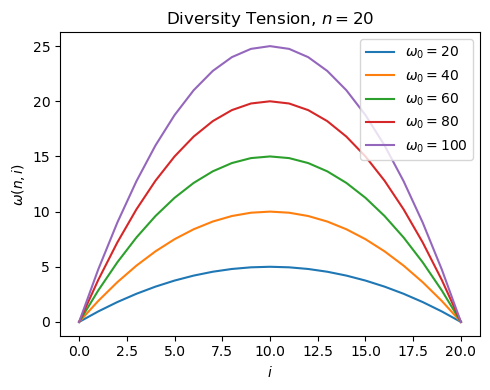

In [4]:
n = nmax 
i_vals = np.arange(0, n+1)
scales = [20, 40, 60, 80, 100]

fig, ax = plt.subplots(figsize=(5, 4))

for scale in scales:
    w_vals = [w_diversity_tension(n, i, scale) for i in i_vals]
    ax.plot(i_vals, w_vals, label=rf"$\omega_0={scale}$")

ax.set_xlabel(r"$i$")
ax.set_ylabel(r"$\omega(n,i)$")
ax.set_title(rf"Diversity Tension, $n={n}$")
ax.legend()
plt.tight_layout()
plt.savefig("./figures/diversity_tension_kernel.png", dpi=300)
plt.show()

Running trajectory integration with allegiance kernel (scale=100.0)...


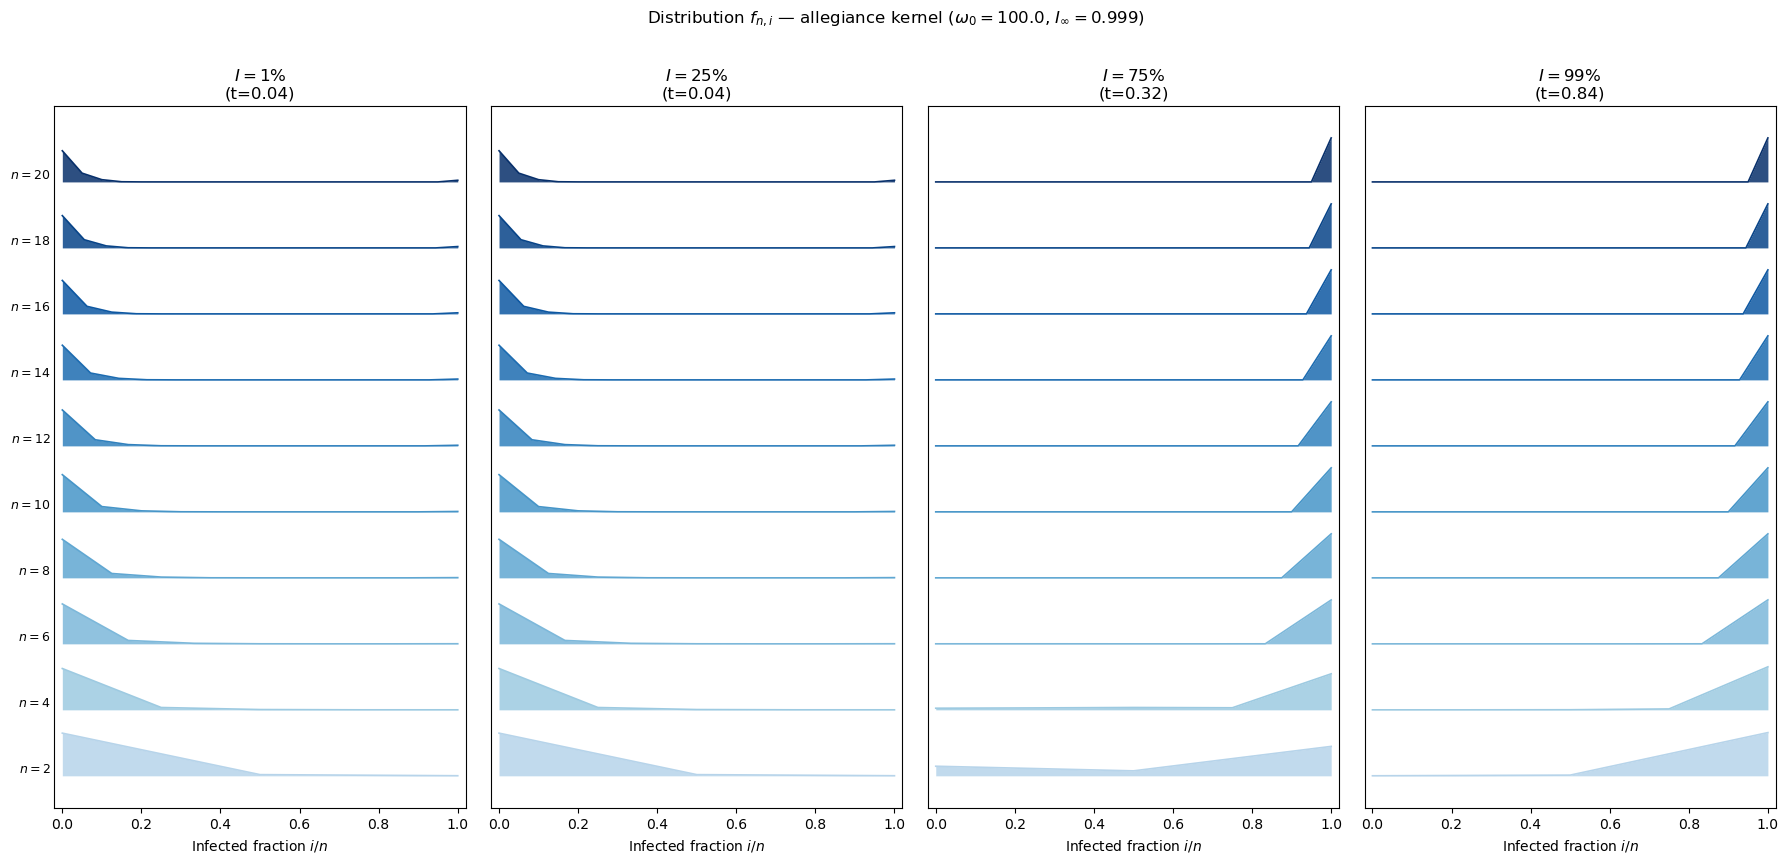

In [5]:
I0 = 1e-3 # code Santi shared starts at 1e-2, but 1e-3 gives a nicer trajectory that doesn't saturate too early, allowing us to see the effect of the kernel more clearly.
traj_points = 5000
t_max = 200.0
scale = 100.0
print(f"Running trajectory integration with allegiance kernel (scale={scale})...")
t_all, I_all, fni_traj = integrate_I_traj_kernel(
    lam=lam_kernel,
    w_func=w_diversity_tension,
    w_args=(scale,),
    state_meta=state_meta,
    nmax=nmax,
    mmax=mmax,
    gm=gm,
    mu=mu,
    nu=nu,
    I0=I0,
    traj_points=traj_points,
    t_max=t_max,
)

I_final = I_all[-1]
targets = [0.01, 0.25, 0.75, 0.99]
snap_indices = [np.argmin(np.abs(I_all - f * I_final)) for f in targets]

n_show = list(range(2, nmax + 1, max(1, nmax // 8)))
if nmax not in n_show:
    n_show.append(nmax)
n_show = sorted(n_show)

spacing = 1.5
cmap = plt.get_cmap("Blues")
colors = [cmap(0.3 + 0.7 * k / max(len(n_show) - 1, 1)) for k in range(len(n_show))]

n_panels = len(snap_indices)
fig, axes = plt.subplots(1, n_panels, figsize=(4.5 * n_panels, len(n_show) * 0.7 + 1.5),
                         sharey=True)

for ax, tidx, target in zip(axes, snap_indices, targets):
    t_snap = t_all[tidx]
    for k, n0 in enumerate(n_show):
        phi_vals = np.arange(n0 + 1) / n0
        dist = fni_traj[tidx, n0, :n0 + 1].copy()
        total = dist.sum()
        if total > 1e-14:
            dist /= total
        baseline = k * spacing
        ax.fill_between(phi_vals, baseline, baseline + dist,
                        alpha=0.85, color=colors[k], linewidth=0)
        ax.plot(phi_vals, baseline + dist, color=colors[k], lw=1.2)
        if ax is axes[0]:
            ax.text(-0.03, baseline, rf"$n={n0}$", ha="right", va="bottom", fontsize=9)
    ax.set_xlabel(r"Infected fraction $i/n$")
    ax.set_title(rf"$I = {int(target*100)}\%$" + f"\n(t={t_snap:.2f})")
    ax.set_yticks([])
    ax.set_xlim(-0.02, 1.02)

fig.suptitle(rf"Distribution $f_{{n,i}}$ — allegiance kernel ($\omega_0={scale}$, $I_{{\infty}}={I_final:.3f}$)", y=1.01)
plt.tight_layout()
plt.savefig(f"./figures/group_state_ridgeline_{scale}.png", dpi=300, bbox_inches="tight")
plt.show()


In [6]:
import numpy as np
import itertools
import time
 
# --- Grid (keep small for local; scale up on VACC) ---
N_LAM = 15                                      # lambda grid points
N_NU  = 15                                      # nu grid points
 
lam_grid = np.logspace(-4, -1, N_LAM)          # 1e-4 to 1e-1
nu_grid  = np.linspace(1.0, 12.0, N_NU)        # 1 (linear) to 12 (strongly nonlinear)
 
# --- Initial conditions (Laurent's two-IC strategy) ---
I0_low  = 1e-3     # invasion attempt
I0_high = 0.99     # persistence attempt
 
# --- Kernel parameters ---
alpha        = 30.0   # diversity-tension amplitude
omega_scalar = 5.0    # paper-style constant omega for baseline run
 
# --- Integration settings (lightweight for local) ---
MU          = 1.0
TRAJ_POINTS = 500    # enough to reach stationarity for most parameter combos
T_MAX       = 20.0    # generous time horizon
 

In [7]:
def run_sweep(lam_grid, nu_grid, w_func, w_args,
              state_meta, nmax, mmax, gm, mu,
              I0_low, I0_high, traj_points, t_max,
              label="sweep"):
    """
    Run a (lambda x nu) parameter sweep with two initial conditions per cell.
 
    Returns
    -------
    I_low  : (N_LAM, N_NU) array  -- stationary I* from low  I0
    I_high : (N_LAM, N_NU) array  -- stationary I* from high I0
    delta  : (N_LAM, N_NU) array  -- I_high - I_low (bistability indicator)
    """
    N_LAM = len(lam_grid)
    N_NU  = len(nu_grid)
 
    I_low   = np.zeros((N_LAM, N_NU))
    I_high  = np.zeros((N_LAM, N_NU))
 
    total  = N_LAM * N_NU
    done   = 0
    t_start = time.time()
 
    for j, nu in enumerate(nu_grid):
        for i, lam in enumerate(lam_grid):
 
            # --- low initial condition ---
            _, I_traj, _ = integrate_I_traj_kernel(
                lam=lam,
                w_func=w_func,
                w_args=w_args,
                state_meta=state_meta,
                nmax=nmax,
                mmax=mmax,
                gm=gm,
                mu=mu,
                nu=nu,
                I0=I0_low,
                traj_points=traj_points,
                t_max=t_max,
                skip_fni_traj=True,
            )
            I_low[i, j] = float(I_traj[-1])
 
            # --- high initial condition ---
            _, I_traj, _ = integrate_I_traj_kernel(
                lam=lam,
                w_func=w_func,
                w_args=w_args,
                state_meta=state_meta,
                nmax=nmax,
                mmax=mmax,
                gm=gm,
                mu=mu,
                nu=nu,
                I0=I0_high,
                traj_points=traj_points,
                t_max=t_max,
                skip_fni_traj=True,
            )
            I_high[i, j] = float(I_traj[-1])
 
            done += 1
            elapsed = time.time() - t_start
            eta     = (elapsed / done) * (total - done)
            print(
                f"[{label}] {done}/{total}  "
                f"lam={lam:.2e}  nu={nu:.1f}  "
                f"I*(low)={I_low[i,j]:.4f}  I*(high)={I_high[i,j]:.4f}  "
                f"ETA {eta:.0f}s",
                end="\r",
            )
 
    print(f"\n[{label}] done in {time.time()-t_start:.1f}s")
    delta = I_high - I_low
    return I_low, I_high, delta

In [8]:
# Cell 3A — kernel run only
print("=== Run A: diversity-tension kernel ===")
I_low_k, I_high_k, delta_k = run_sweep(
    lam_grid, nu_grid,
    w_func=w_diversity_tension,
    w_args=(alpha,),
    state_meta=state_meta,
    nmax=nmax, mmax=mmax, gm=gm,
    mu=MU,
    I0_low=I0_low, I0_high=I0_high,
    traj_points=TRAJ_POINTS, t_max=T_MAX,
    label="kernel",
)

np.savez_compressed(
    "Files/sweep_kernel_only.npz",
    lam_grid=lam_grid, nu_grid=nu_grid,
    I_low_k=I_low_k, I_high_k=I_high_k, delta_k=delta_k,
    alpha=alpha, mu=MU, I0_low=I0_low, I0_high=I0_high,
)
print("Kernel run saved to Files/sweep_kernel_only.npz")

=== Run A: diversity-tension kernel ===
 lsoda--  warning..internal t (=r1) and h (=r2) are  00  I*(high)=1.0000  ETA 9sss
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.6099169890971D-02   r2 =  0.3038556964714D-18
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.6099170090476D-02   r2 =  0.3391132727124D-18
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.6099170090476D-02   r2 =  0.8173086426194D-19
 lsoda--  warning..internal t (=r1) and h (=r2) are  
       such that in the machine, t + h = t on the next step  
       (h = step size). solver will continue anyway  
      in above,  r1 =  0.6099170090476

capi_return is NULL
Call-back cb_f_in_lsoda__user__routines failed.


KeyboardInterrupt: 

In [ ]:
# Cell 3B — constant omega baseline + merge + save
def w_constant(n, i, omega):
      return omega
dat = np.load("Files/sweep_kernel_only.npz")
I_low_k  = dat["I_low_k"]
I_high_k = dat["I_high_k"]
delta_k  = dat["delta_k"]

print("=== Run B: constant omega baseline ===")
I_low_c, I_high_c, delta_c = run_sweep(
    lam_grid, nu_grid,
    w_func=w_constant,
    w_args=(omega_scalar,),
    state_meta=state_meta,
    nmax=nmax, mmax=mmax, gm=gm,
    mu=MU,
    I0_low=I0_low, I0_high=I0_high,
    traj_points=TRAJ_POINTS, t_max=T_MAX,
    label="constant-w",
)

np.savez_compressed(
    "Files/sweep_local.npz",
    lam_grid=lam_grid, nu_grid=nu_grid,
    I_low_k=I_low_k,  I_high_k=I_high_k,  delta_k=delta_k,
    I_low_c=I_low_c,  I_high_c=I_high_c,  delta_c=delta_c,
    alpha=alpha, omega_scalar=omega_scalar,
    mu=MU, I0_low=I0_low, I0_high=I0_high,
)
print("Full sweep saved to Files/sweep_local.npz")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
 
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
 
LAM_LABELS = [f"{v:.1e}" for v in lam_grid]
NU_LABELS  = [f"{v:.1f}" for v in nu_grid]
 
# shared color scale for delta panels so they're directly comparable
vmax = max(delta_k.max(), delta_c.max())
norm = Normalize(vmin=0, vmax=vmax)
cmap_delta = "YlOrBr"
cmap_diff  = "RdBu_r"
 
def make_heatmap(ax, data, title, cmap, norm, xlabel=True):
    im = ax.imshow(
        data.T,                   # rows = nu, cols = lambda
        origin="lower",
        aspect="auto",
        cmap=cmap,
        norm=norm,
        extent=[0, len(lam_grid), 0, len(nu_grid)],
    )
    ax.set_title(title, fontsize=13)
    ax.set_xticks(np.arange(len(lam_grid)) + 0.5)
    ax.set_xticklabels(
        [f"{v:.0e}" for v in lam_grid],
        rotation=45, ha="right", fontsize=7,
    )
    ax.set_yticks(np.arange(len(nu_grid)) + 0.5)
    ax.set_yticklabels([f"{v:.1f}" for v in nu_grid], fontsize=7)
    if xlabel:
        ax.set_xlabel(r"$\lambda$", fontsize=12)
    return im
 
# Panel 1: kernel bistability
im1 = make_heatmap(
    axes[0], delta_k,
    rf"Kernel  ($\alpha={alpha}$)" + "\n" + r"$\Delta I^* = I^*_\mathrm{high} - I^*_\mathrm{low}$",
    cmap_delta, norm,
)
axes[0].set_ylabel(r"$\nu$", fontsize=12)
fig.colorbar(im1, ax=axes[0], label=r"$\Delta I^*$")
 
# Panel 2: constant omega bistability
im2 = make_heatmap(
    axes[1], delta_c,
    rf"Constant $\omega={omega_scalar}$" + "\n" + r"$\Delta I^* = I^*_\mathrm{high} - I^*_\mathrm{low}$",
    cmap_delta, norm,
)
fig.colorbar(im2, ax=axes[1], label=r"$\Delta I^*$")
 
# Panel 3: difference (kernel minus baseline)
diff = delta_k - delta_c
vlim = np.abs(diff).max()
norm_diff = Normalize(vmin=-vlim, vmax=vlim)
im3 = make_heatmap(
    axes[2], diff,
    r"Difference (kernel $-$ baseline)" + "\n" + r"red = kernel enhances bistability",
    cmap_diff, norm_diff,
)
fig.colorbar(im3, ax=axes[2], label=r"$\Delta\Delta I^*$")
 
fig.suptitle(
    f"CNS network  |  bistability indicator  |  "
    rf"$\mu={MU}$,  $I_0 \in \{{{I0_low:.0e},\ {I0_high}\}}$",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("figures/sweep_bistability_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved figures/sweep_bistability_comparison.png")
